In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [4]:
image_dir = "../data/image"
mask_dir = "../data/mask"
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))
print("Number of images:", len(images))
print("Number of masks:", len(masks))



Number of images: 290
Number of masks: 290


In [5]:
img = cv2.imread(os.path.join(image_dir, images[0]))
mask = cv2.imread(os.path.join(mask_dir, masks[0]), cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)

Image shape: (551, 893, 3)
Mask shape : (551, 893)


In [6]:
print(np.unique(mask))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

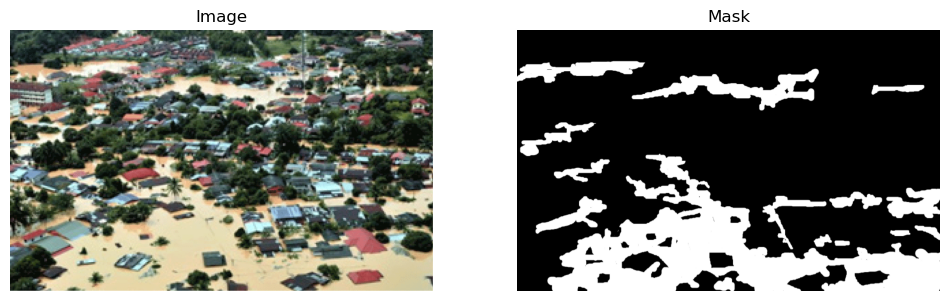

In [7]:
idx = 0

img = cv2.imread(os.path.join(image_dir, images[idx]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_dir, masks[idx]), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [8]:
print(mask.min())
print(mask.max())
print(mask.mean())

0
255
63.62130748735375


In [13]:
IMG_HEIGHT = 256
IMG_WIDTH = 256

X = []
Y = []

for img_name in images:
    
    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)

    # Convert image filename to mask filename
    mask_name = img_name.replace(".jpg", ".png")
    mask_path = os.path.join(mask_dir, mask_name)

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0

    # Read mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print("Missing mask:", mask_path)
        continue

    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))

    # Convert to binary
    mask = (mask > 127).astype(np.float32)

    X.append(img)
    Y.append(mask)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(290, 256, 256, 3)
(290, 256, 256)


In [14]:
Y = np.expand_dims(Y, axis=-1)

print(X.shape)
print(Y.shape)

(290, 256, 256, 3)
(290, 256, 256, 1)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (203, 256, 256, 3)
Validation: (43, 256, 256, 3)
Test: (44, 256, 256, 3)


In [19]:
def unet_model(input_shape=(256,256,3)):

    inputs = Input(input_shape)

    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(128, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(32, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(32, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(16, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(16, 3, activation='relu', padding='same')(c7)

    outputs = Conv2D(1, 1, activation='sigmoid')(c7)

    return Model(inputs, outputs)

In [20]:
def dice_coef(y_true, y_pred, smooth=1):

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) +
        tf.keras.backend.sum(y_pred_f) +
        smooth
    )

In [21]:
model = unet_model()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[dice_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 16)      │             448 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 256, 256, 16)      │           2,320 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 128, 128, 16)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 128, 128, 32)      │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 128, 128, 32)      │           9,248 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 64, 64, 32)        │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 64, 64, 64)        │          36,928 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 32, 32, 64)        │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 32, 32, 128)       │          73,856 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 128)       │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 64, 64, 128)       │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64, 64, 192)       │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 64, 64, 64)        │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 64, 64, 64)        │          36,92

 Total params: 487,297 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=4
)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - dice_coef: 0.4431 - loss: 0.6531 - val_dice_coef: 0.4898 - val_loss: 0.5434
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - dice_coef: 0.5177 - loss: 0.5894 - val_dice_coef: 0.6029 - val_loss: 0.4436
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - dice_coef: 0.5863 - loss: 0.4950 - val_dice_coef: 0.6041 - val_loss: 0.4503
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - dice_coef: 0.6152 - loss: 0.4697 - val_dice_coef: 0.6333 - val_loss: 0.4154
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 49s 955ms/step - dice_coef: 0.6169 - loss: 0.4484 - val_dice_coef: 0.6722 - val_loss: 0.4256
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - dice_coef: 0.6682 - loss: 0.4206 - val_dice_coef: 0.6609 - val_loss: 0.3872
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - dice_coef: 0.6723 - loss: 0.4144 - val_dice_coef: 0.5116 - val_loss: 0.5366
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - dice_coef: 0.6616 - loss: 0.4201 - val_dice_coef:

In [23]:
model.save("../models/flood_unet.keras")

In [24]:
results = model.evaluate(X_test, Y_test)

print("Test Loss:", results[0])
print("Test Dice:", results[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - dice_coef: 0.7875 - loss: 0.2769   
Test Loss: 0.2769012749195099
Test Dice: 0.7875137329101562


In [25]:
pred = model.predict(X_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


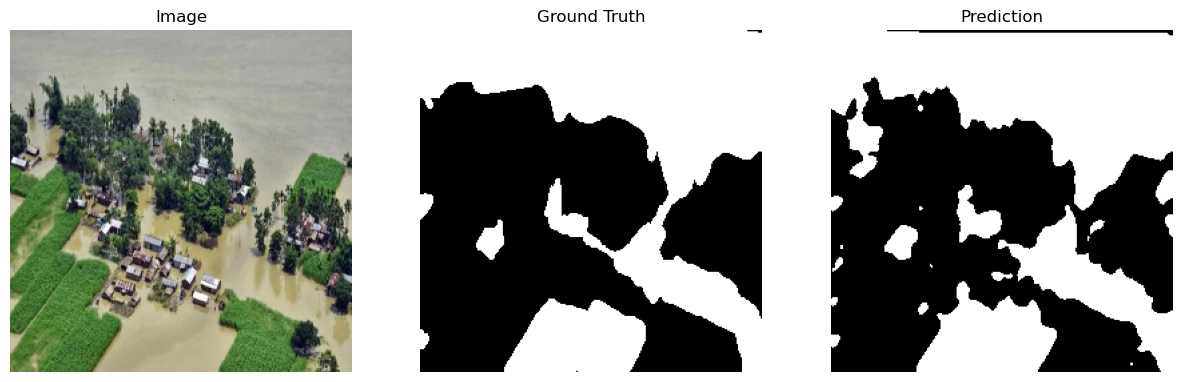

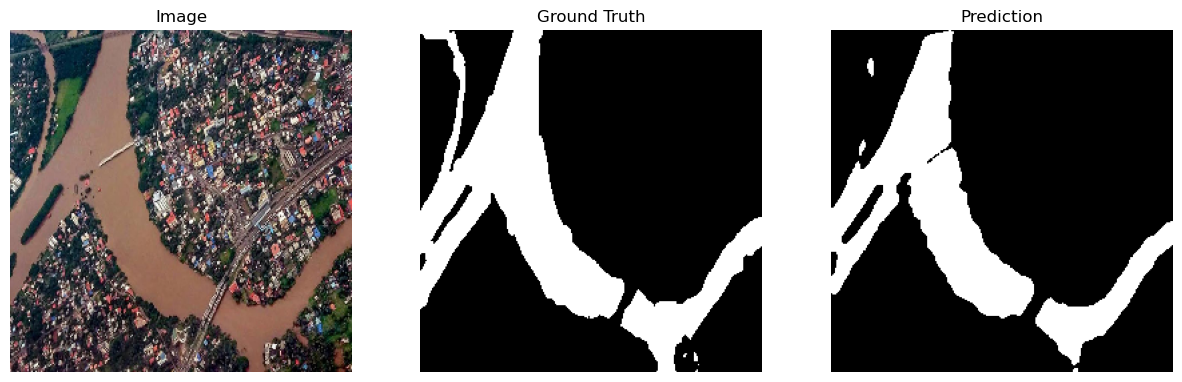

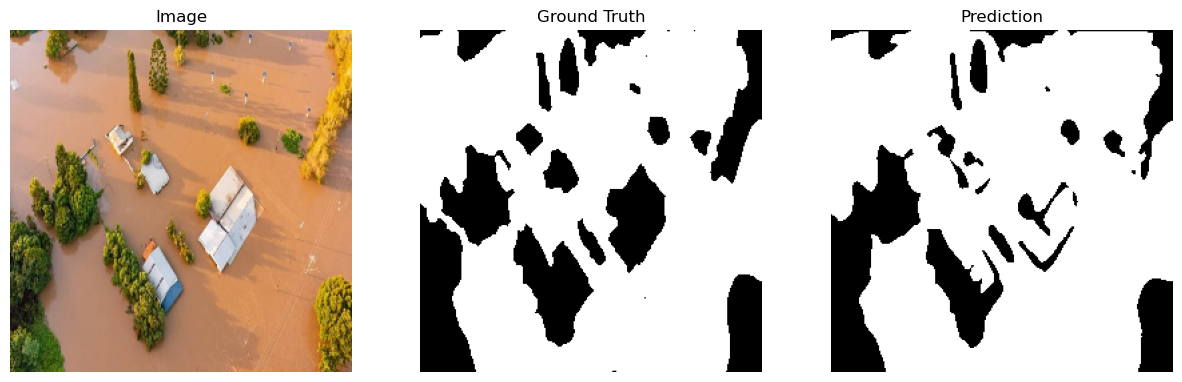

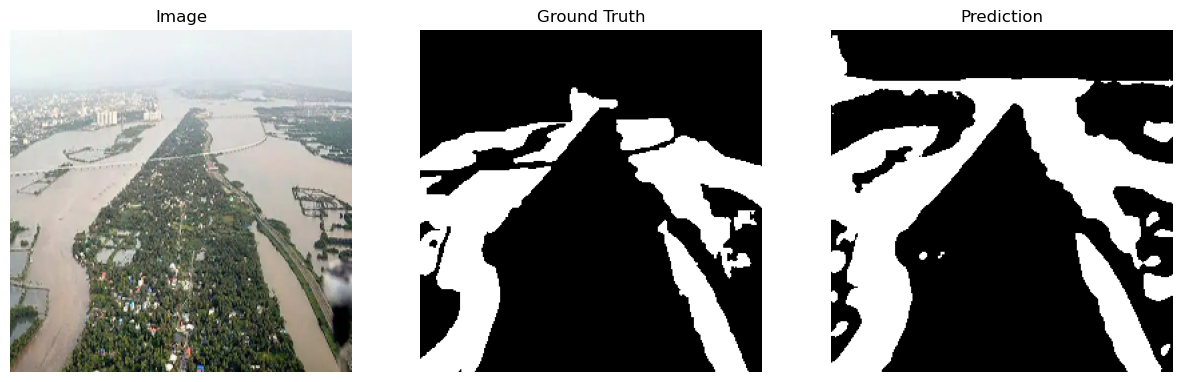

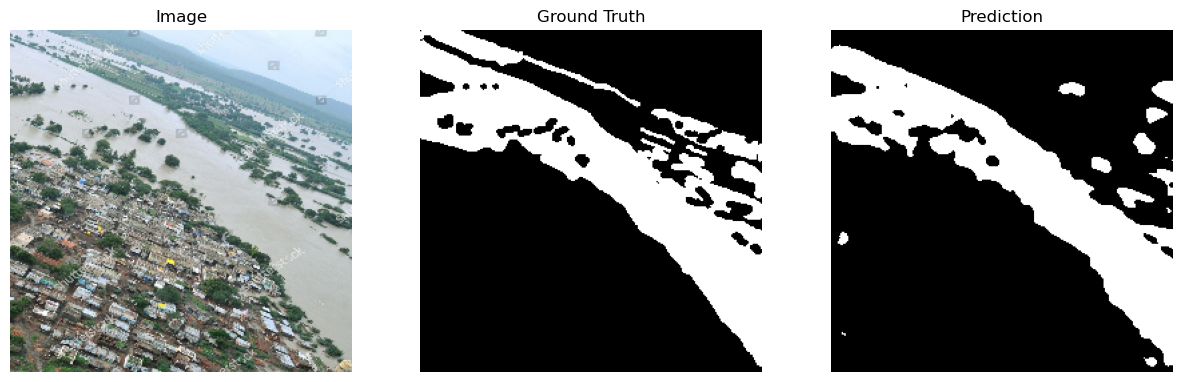

In [26]:
preds = model.predict(X_test[:5])

for i in range(5):

    pred_mask = (preds[i] > 0.5).astype(np.uint8)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(Y_test[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()